In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Lambda, Cropping2D, BatchNormalization, Dropout, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
# from tensorflow.keras.metrics import MeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError, CosineSimilarity

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from datetime import datetime
import pandas as pd
# from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


import albumentations as A
import wandb
from wandb.integration.keras import WandbCallback

import os
from datetime import datetime
import cv2

import warnings

warnings.filterwarnings("ignore") 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '0'

2024-09-06 18:48:16.545932: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-06 18:48:16.631776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-06 18:48:16.664285: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-06 18:48:16.674025: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-06 18:48:16.754768: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# GPUS disponibles
physical_devices = tf.config.list_physical_devices('GPU')
print("Dispositivos físicos:", physical_devices)

if physical_devices:
    try:
      
        tf.config.set_visible_devices(physical_devices[0], 'GPU')

        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)

        logical_devices = tf.config.list_logical_devices('GPU')
        print("Dispositivos lógicos:", logical_devices)
    except RuntimeError as e:
        print(e)
else:
    print("No se encontraron GPUs disponibles.")

Dispositivos físicos: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Dispositivos lógicos: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]


I0000 00:00:1725666499.130638    4611 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725666499.228468    4611 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725666499.228604    4611 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725666499.230552    4611 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [3]:
import os
import numpy as np
import cv2
from tensorflow.keras.utils import Sequence
import albumentations as A

# transformaciones
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2, hue=0.1, p=0.4),
    A.RandomBrightnessContrast(p=0.4),
    A.RandomGamma(gamma_limit=(50, 250), p=0.4),
    A.HueSaturationValue(
        hue_shift_limit=20,
        sat_shift_limit=30,
        val_shift_limit=20,
        p=0.4
    ),
    A.FancyPCA(alpha=0.1, p=0.4),
    A.GaussianBlur(blur_limit=(1, 3), p=0.4),
])

val_transform = A.Compose([])

class DataGenerator(Sequence):
    def __init__(self, x_set, y_set, batch_size, transform=None):
        self.x = x_set
        self.y = y_set
        self.batch_size = batch_size
        self.transform = transform

    def __len__(self):
        return int(np.ceil(len(self.x) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_x = self.x[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size:(idx + 1) * self.batch_size]

        if self.transform:
            augmented_images = []
            augmented_labels = []

            for img, label in zip(batch_x, batch_y):
                transformed = self.transform(image=img)
                img = transformed["image"]

                # verifica el numero de canales y convierte a 3 si es necesario
                if img.shape[-1] == 4:
                    img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)

                if "horizontal_flip" in transformed:
                    if transformed["horizontal_flip"]:
                        label[0] = -label[0]  
                augmented_images.append(img)
                augmented_labels.append(label)

            batch_x = np.array(augmented_images)
            batch_y = np.array(augmented_labels)

        return batch_x, batch_y

# def get_images_array(df, base_path):
#     required_columns = ['image_name', 'steer']
#     for column in required_columns:
#         if column not in df.columns:
#             raise ValueError(f"La columna '{column}' no se encuentra en el DataFrame.")

#     steering_values = df['steer'].to_numpy()
#     image_paths = df['image_name'].tolist()

#     if len(image_paths) != len(steering_values):
#         raise ValueError("El número de nombres de imágenes no coincide con el número de valores de dirección.")

#     imagenes = []
#     labels = []

#     for index, image_path in enumerate(image_paths):
#         full_image_path = os.path.join(base_path, image_path)
#         if not os.path.isfile(full_image_path):
#             raise FileNotFoundError(f"La imagen {full_image_path} no se encuentra.")

#         # imagen = cv2.imread(full_image_path, cv2.IMREAD_UNCHANGED)
#         imagen = cv2.imread(full_image_path, cv2.IMREAD_COLOR)
#         if imagen is None:
#             raise ValueError(f"Error al leer la imagen {full_image_path}.")

#         img_cropped_resized = cv2.resize(imagen[200:-1, :], (200, 66))
#         array_imagen = np.array(img_cropped_resized)
#         # array_imagen_yuv = cv2.cvtColor(array_imagen, cv2.COLOR_RGB2YUV)

#         imagenes.append(array_imagen)
#         labels.append(steering_values[index])

#     return np.array(imagenes), np.array(labels)



In [4]:
import cv2
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_image(image_info):
    image_path, steer_value, base_path = image_info
    full_image_path = os.path.join(base_path, image_path)
    
    if not os.path.isfile(full_image_path):
        raise FileNotFoundError(f"La imagen {full_image_path} no se encuentra.")
    
    imagen = cv2.imread(full_image_path, cv2.IMREAD_COLOR)
    if imagen is None:
        raise ValueError(f"Error al leer la imagen {full_image_path}.")
    
    img_cropped_resized = cv2.resize(imagen[200:-1, :], (200, 66))
    array_imagen = np.array(img_cropped_resized)
    
    return array_imagen, steer_value

def get_images_array(df, base_path, max_workers=8):
    required_columns = ['image_name', 'steer']
    for column in required_columns:
        if (column) not in df.columns:
            raise ValueError(f"La columna '{column}' no se encuentra en el DataFrame.")

    steering_values = df['steer'].to_numpy()
    image_paths = df['image_name'].tolist()

    if len(image_paths) != len(steering_values):
        raise ValueError("El número de nombres de imágenes no coincide con el número de valores de dirección.")

    imagenes = []
    labels = []

    image_info_list = [(image_paths[i], steering_values[i], base_path) for i in range(len(image_paths))]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_image = {executor.submit(process_image, info): info for info in image_info_list}
        for future in as_completed(future_to_image):
            try:
                imagen, label = future.result()
                imagenes.append(imagen)
                labels.append(label)
            except Exception as exc:
                print(f'Error al procesar la imagen: {exc}')

    return np.array(imagenes), np.array(labels)


In [5]:
# data_path = '/home/canveo/carla_ros2_ws/carla_data_1/carla_data.csv'
# images_name = pd.read_csv(data_path)['image_name'].tolist()

# # imagenes, steering_values = get_images_array(data_path, images_name, 'recto')
# base_path = '/home/canveo/carla_ros2_ws/dataset'

# imagenes, labels = load_all_datasets(base_path)

# print("Imágenes shape:", imagenes.shape)
# print("Valores de dirección shape:", labels.shape)

In [6]:
import pandas as pd

base_path = '/home/canveo/carla_ws/dataset'  


dataframes = []

for i in range(1, 13):
    folder_name = f"carla_data_{i}"
    folder_path = os.path.join(base_path, folder_name)
    csv_path = os.path.join(folder_path, "data.csv")
    
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        
        df = df[["image_name", "steer", "throttle", "brake"]]
        
        df["image_name"] = df["image_name"].apply(lambda x: f"{folder_name}/images/{x}")
        
        dataframes.append(df)

final_df = pd.concat(dataframes, ignore_index=True)
print(final_df.head())
# final_df.to_csv(os.path.join(base_path, "combined_data.csv"), index=False)


                                   image_name  steer  throttle  brake
0  carla_data_1/images/frame1724103205448.png    0.0       0.0    0.0
1  carla_data_1/images/frame1724103205496.png    0.0       0.0    1.0
2  carla_data_1/images/frame1724103205540.png    0.0       0.0    1.0
3  carla_data_1/images/frame1724103205565.png    0.0       0.0    1.0
4  carla_data_1/images/frame1724103205587.png    0.0       0.0    1.0


In [7]:
image = cv2.imread('/home/canveo/carla_ws/dataset/carla_data_1/images/frame1724103205448.png')
height, width, channels = image.shape
b, g, r = image[0, 0]
print(f"Anchura: {width}, Altura: {height}, Canales: {channels}")
print(f"Valores de los canales (BGR): {b}, {g}, {r}")

Anchura: 800, Altura: 600, Canales: 3
Valores de los canales (BGR): 115, 110, 98


In [8]:
num_bins = 25
samples_per_bin = 30000
hist, bins = np.histogram(final_df['steer'], num_bins)

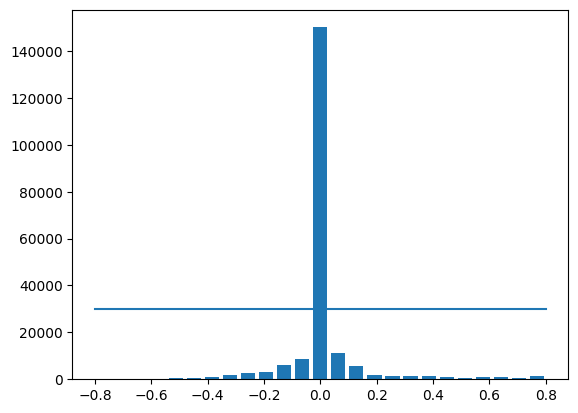

In [9]:
center = (bins[:-1]+ bins[1:]) * 0.5

plt.bar(center, hist, width=0.05)

plt.plot((np.min(final_df['steer']), np.max(final_df['steer'])), (samples_per_bin, samples_per_bin))  

In [10]:
print("Número total de datos: ", len(final_df))

Número total de datos:  202384


In [11]:
remove_list = []
for j in range(num_bins):
  list_ = []
  for i in range(len(final_df['steer'])):
    if final_df['steer'][i] >= bins[j] and final_df['steer'][i] <= bins[j+1]:
      list_.append(i)
  list_ = shuffle(list_)
  list_ = list_[samples_per_bin:]
  remove_list.extend(list_)
print('La cantidad de datos eliminados es {}:'.format(len(remove_list)))

La cantidad de datos eliminados es 120123:


In [12]:
final_df.drop(final_df.index[remove_list], inplace=True)
print('Cantidad de datos retenidos es {}'.format(len(final_df)))

Cantidad de datos retenidos es 82261


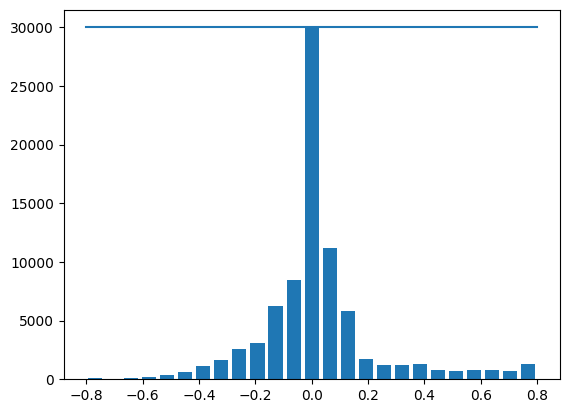

In [13]:
hist, _ = np.histogram(final_df['steer'], (num_bins))

plt.bar(center, hist, width=0.05)

plt.plot((np.min(final_df['steer']), np.max(final_df['steer'])), (samples_per_bin, samples_per_bin))

In [14]:
ranges = [x for x in np.arange(-1.0, 1.01, 0.08)]   # 25 intervalos
grouped_counts = final_df.groupby(pd.cut(final_df['steer'], ranges), observed=False).count()
grouped_counts

,image_name,steer,throttle,brake
steer,,,,
"(-1.0, -0.92]",0,0,0,0
"(-0.92, -0.84]",0,0,0,0
"(-0.84, -0.76]",64,64,64,64
"(-0.76, -0.68]",59,59,59,59
"(-0.68, -0.6]",116,116,116,116
"(-0.6, -0.52]",309,309,309,309
"(-0.52, -0.44]",592,592,592,592
"(-0.44, -0.36]",1264,1264,1264,1264
"(-0.36, -0.28]",2108,2108,2108,2108


In [15]:
desired_count = 10000 # muestras por intervalo

resampled = pd.DataFrame()   # para muestras aumentadas

for small_r in np.arange(-1, 1.01, 0.04):
    part_df = final_df.loc[(final_df['steer'] >= small_r) & (final_df['steer'] < small_r + 0.04)]
    
    if part_df.shape[0] > 0:
        repeat_factor = max(1, desired_count // part_df.shape[0])
        
        part_df_repeated = pd.concat([part_df] * repeat_factor, ignore_index=True)
        
        remaining_samples = desired_count - part_df_repeated.shape[0]
        if remaining_samples > 0:
            part_df_remaining = part_df.sample(remaining_samples, replace=True, random_state=1)
            part_df_repeated = pd.concat([part_df_repeated, part_df_remaining], ignore_index=True)
        
  
        resampled = pd.concat([resampled, part_df_repeated], ignore_index=True)

In [16]:
resampled

,image_name,steer,throttle,brake
0,carla_data_7/images/frame1724108525455.png,-0.8,0.193225,0.0
1,carla_data_7/images/frame1724108525479.png,-0.8,0.193225,0.0
2,carla_data_7/images/frame1724108525504.png,-0.8,0.220553,0.0
3,carla_data_7/images/frame1724108525526.png,-0.8,0.220553,0.0
4,carla_data_7/images/frame1724108525551.png,-0.8,0.220553,0.0
...,...,...,...,...
433698,carla_data_2/images/frame1724104848316.png,0.8,0.249178,0.0
433699,carla_data_7/images/frame1724109199999.png,0.8,0.850000,0.0
433700,carla_data_3/images/frame1724105871180.png,0.8,0.253004,0.0
433701,carla_data_3/images/frame1724106151603.png,0.8,0.299607,0.0


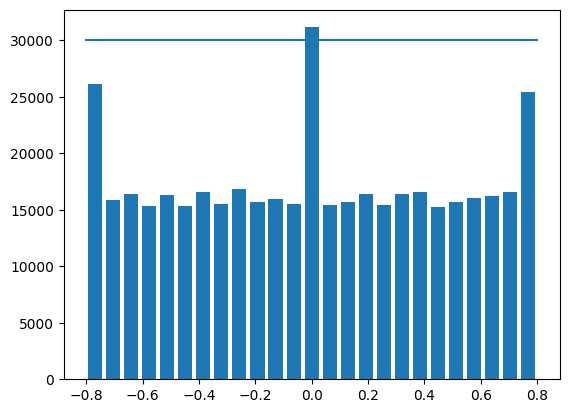

In [17]:
hist, _ = np.histogram(resampled['steer'], (num_bins))

plt.bar(center, hist, width=0.05)

plt.plot((np.min(resampled['steer']), np.max(resampled['steer'])), (samples_per_bin, samples_per_bin))

In [18]:
len(resampled)

433703

In [19]:
base_path = '/home/canveo/carla_ws/dataset' 
all_images, all_labels = get_images_array(resampled, base_path)

In [20]:
X_train, X_val, y_train, y_val = train_test_split(all_images, all_labels, test_size=0.25, random_state=42)

In [21]:
X_train.shape

(325277, 66, 200, 3)

In [22]:
# import wandb
# # from wandb.keras import WandbCallback
# from wandb.integration.keras import WandbCallback

# # Inicializar wandb
# wandb.init(project="pilotnet-hyperparameter-tuning")

# # Configurar los hiperparámetros que se van a optimizar
# config = wandb.config
# config.learning_rate = 0.001  # Tasa de aprendizaje inicial
# config.epochs = 350           # Número de épocas inicial
# # config.batch_size = 32    
# # 
# # Definir el sweep
# # sweep_configuration = {
# #     'method': 'random',
# #     'metric': {'name': 'loss', 'goal': 'minimize'},
# #     'parameters': 
# #     {
# #         'learning_rate': {'values': [0.001, 0.0001, 0.00001]},
# #         'epochs': {'values': [50, 100, 200]},
# #         'batch_size': {'values': [32, 64, 128]}
# #     }
# # }   

In [23]:
import json
import os

class TrainingLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_dir, params):
        super(TrainingLogger, self).__init__()
        self.log_dir = log_dir
        self.params = params

    def on_train_begin(self, logs=None):
        with open(os.path.join(self.log_dir, 'training_params.json'), 'w') as f:
            json.dump(self.params, f)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        with open(os.path.join(self.log_dir, f'epoch_{epoch}_logs.json'), 'w') as f:
            json.dump(logs, f)


In [24]:
import datetime
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard

base_log_dir = "./logs"

experiment_name = f"experiment_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
experiment_dir = os.path.join(base_log_dir, experiment_name)

os.makedirs(experiment_dir, exist_ok=True)

batch_size = 32
learning_rate = 0.0001
dropout = 0.1

training_params = {
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "dropout": dropout,
    "epochs": 200,
}

training_logger_callback = TrainingLogger(experiment_dir, training_params)

with open(os.path.join(experiment_dir, 'params.json'), 'w') as f:
    json.dump(training_params, f)

tensorboard_callback = TensorBoard(log_dir=experiment_dir, histogram_freq=1)


In [25]:
train_dataset = DataGenerator(X_train, y_train, batch_size=training_params["batch_size"] , transform=train_transform)
val_dataset = DataGenerator(X_val, y_val, batch_size=training_params["batch_size"] , transform=val_transform)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# wandb_cb = WandbCallback()

In [27]:
img_shape = (66, 200, 3)

learning_rate = training_params["learning_rate"]    # 0.001, 0.0001
dropout = training_params["dropout"]

# learning_rate = wandb.config.learning_rate
model = Sequential()
model.add(BatchNormalization(epsilon=0.001, axis=-1, input_shape=img_shape))


model.add(Conv2D(24, (5, 5), strides=(2, 2), activation='relu'))
model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='relu'))
model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(Flatten())
model.add(Dense(1164, activation="relu"))
model.add(Dropout(dropout))
model.add(Dense(100, activation='relu'))
model.add(Dropout(dropout))
model.add(Dense(50, activation='relu'))
model.add(Dropout(dropout))
model.add(Dense(10, activation='relu'))
model.add(Dropout(dropout))
model.add(Dense(1))
# adam = Adam(learning_rate=config.learning_rate)
adam = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=adam, 
    loss='mse',
    metrics=['mse', 'mae']
)   

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 66, 200, 3)     │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1164)           │     1,342,092 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1164)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │       116,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,595,523 (6.09 MB)

 Trainable params: 1,595,517 (6.09 MB)

 Non-trainable params: 6 (24.00 B)

In [29]:
# history = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     # epochs=config.epochs,
#     epochs=400,
#     # batch_size=config.batch_size,
#     # batch_size=32,
#     # callbacks=[WandbCallback()]
#     callbacks=[es]
# )

# Crea el callback de TensorBoard
tensorboard_callback = TensorBoard(log_dir=experiment_dir, histogram_freq=1)


history = model.fit(train_dataset,
          epochs=training_params["epochs"],
          # batch_size=batch_size,
          validation_data=val_dataset,
          callbacks=[tensorboard_callback, early_stopping_callback, training_logger_callback])


Epoch 1/200


I0000 00:00:1725667503.631404    4735 service.cc:146] XLA service 0x7c74f00018f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1725667503.631423    4735 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2024-09-06 19:05:03.670646: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-09-06 19:05:03.868553: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


    9/10165 ━━━━━━━━━━━━━━━━━━━━ 2:31 15ms/step - loss: 0.2332 - mae: 0.4147 - mse: 0.2332

I0000 00:00:1725667506.997829    4735 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10161/10165 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0696 - mae: 0.1907 - mse: 0.0696

2024-09-06 19:08:19.241842: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_103', 240 bytes spill stores, 240 bytes spill loads



10165/10165 ━━━━━━━━━━━━━━━━━━━━ 203s 20ms/step - loss: 0.0696 - mae: 0.1907 - mse: 0.0696 - val_loss: 0.0056 - val_mae: 0.0525 - val_mse: 0.0056
Epoch 2/200
10165/10165 ━━━━━━━━━━━━━━━━━━━━ 208s 20ms/step - loss: 0.0129 - mae: 0.0823 - mse: 0.0129 - val_loss: 0.0028 - val_mae: 0.0390 - val_mse: 0.0028
Epoch 3/200
10165/10165 ━━━━━━━━━━━━━━━━━━━━ 205s 20ms/step - loss: 0.0100 - mae: 0.0721 - mse: 0.0100 - val_loss: 0.0023 - val_mae: 0.0368 - val_mse: 0.0023
Epoch 4/200
10165/10165 ━━━━━━━━━━━━━━━━━━━━ 197s 19ms/step - loss: 0.0087 - mae: 0.0680 - mse: 0.0087 - val_loss: 0.0016 - val_mae: 0.0297 - val_mse: 0.0016
Epoch 5/200
10165/10165 ━━━━━━━━━━━━━━━━━━━━ 189s 19ms/step - loss: 0.0079 - mae: 0.0646 - mse: 0.0079 - val_loss: 0.0013 - val_mae: 0.0267 - val_mse: 0.0013
Epoch 6/200
10165/10165 ━━━━━━━━━━━━━━━━━━━━ 188s 18ms/step - loss: 0.0077 - mae: 0.0639 - mse: 0.0077 - val_loss: 0.0016 - val_mae: 0.0303 - val_mse: 0.0016
Epoch 7/200
10165/10165 ━━━━━━━━━━━━━━━━━━━━ 188s 18ms/step - lo

In [30]:
# path_name = os.path.join('model/pilotnet_agos28_199ep.h5')
# model.save(path_name)
# model.save('model/pilonet_agost28_199ep.keras')
model.save(os.path.join(experiment_dir, 'trained_model.h5'))
model.save(os.path.join(experiment_dir, 'trained_model.keras'))

In [31]:
print(history.history.keys())

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])


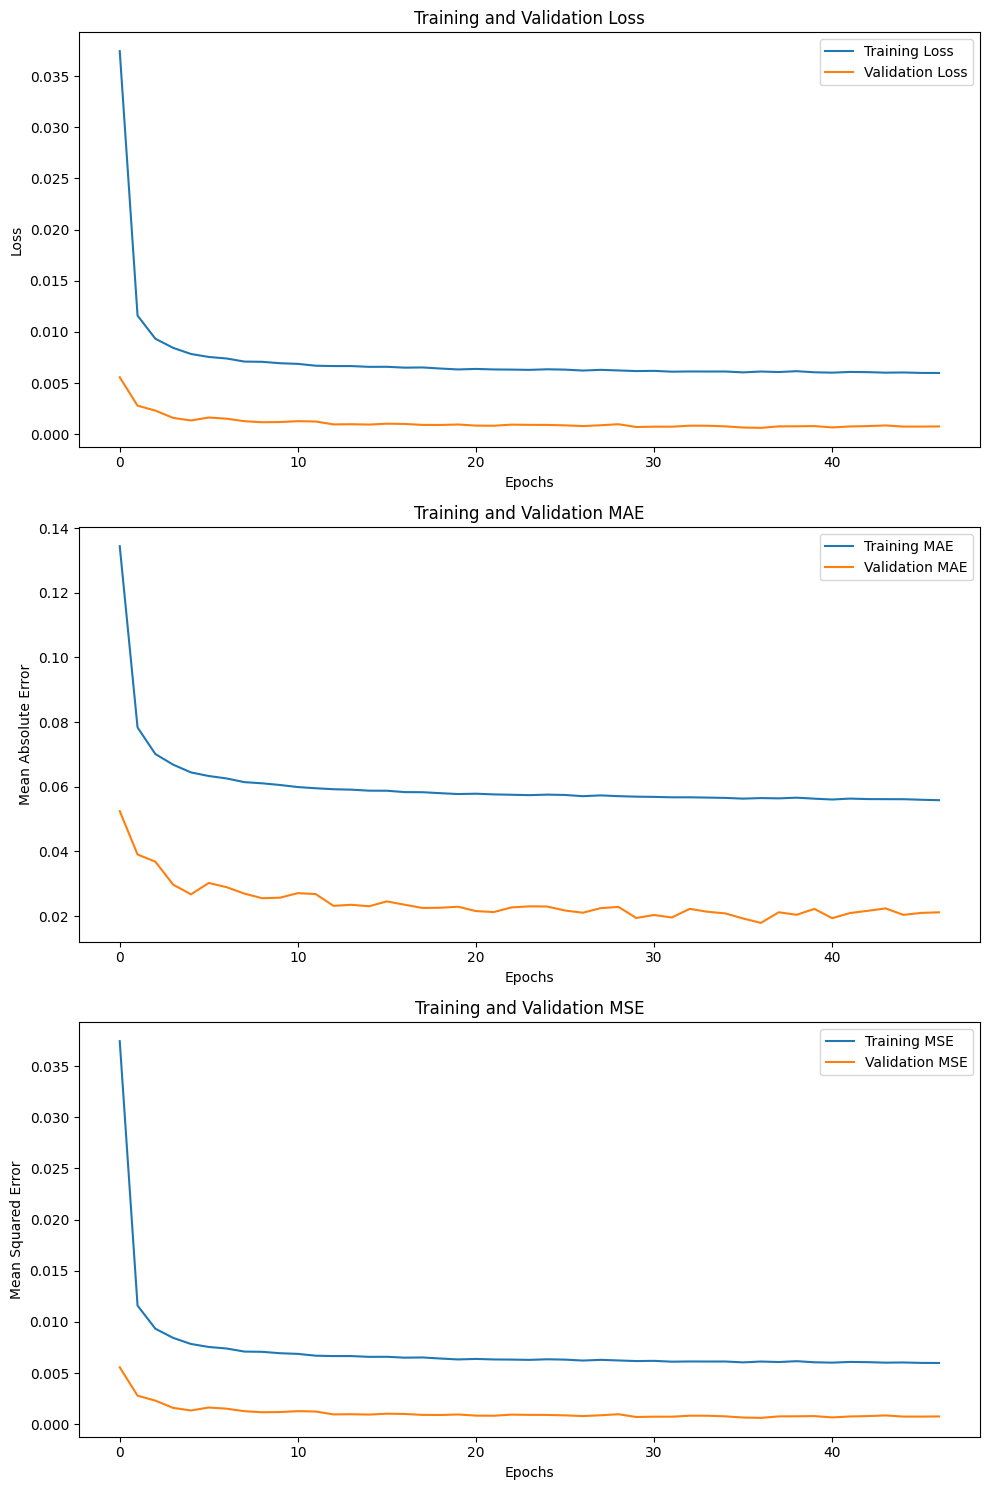

In [32]:
# import matplotlib.pyplot as plt

# def plot_history(history):
#     plt.figure(figsize=(12, 8))
    
#     # Plot MSE (usando 'loss' en lugar de 'mse' ya que no hay 'mse' en las claves)
#     plt.subplot(2, 1, 1)
#     plt.plot(history.history['steering_angle_loss'], label='Train Steering MSE')
#     plt.plot(history.history['val_steering_angle_loss'], label='Val Steering MSE')
#     plt.plot(history.history['throttle_brake_loss'], label='Train Throttle MSE')
#     plt.plot(history.history['val_throttle_brake_loss'], label='Val Throttle MSE')
#     plt.title('Mean Squared Error (MSE)')
#     plt.ylabel('MSE')
#     plt.xlabel('Epoch')
#     plt.legend()
    
#     # Plot MAE
#     plt.subplot(2, 1, 2)
#     plt.plot(history.history['steering_angle_mae'], label='Train Steering MAE')
#     plt.plot(history.history['val_steering_angle_mae'], label='Val Steering MAE')
#     plt.plot(history.history['throttle_brake_mae'], label='Train Throttle MAE')
#     plt.plot(history.history['val_throttle_brake_mae'], label='Val Throttle MAE')
#     plt.title('Mean Absolute Error (MAE)')
#     plt.ylabel('MAE')
#     plt.xlabel('Epoch')
#     plt.legend()
    
#     plt.tight_layout()
#     plt.show()

# # Llama a la función para graficar
# plot_history(history)
import matplotlib.pyplot as plt


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# MAE plot
ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('Training and Validation MAE')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Mean Absolute Error')
ax2.legend()

# MSE plot
ax3.plot(history.history['mse'], label='Training MSE')
ax3.plot(history.history['val_mse'], label='Validation MSE')
ax3.set_title('Training and Validation MSE')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Mean Squared Error')
ax3.legend()

plt.tight_layout()
plt.show()


3389/3389 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step
Shape of pred_steering: (108426, 1)
Shape of y_val: (108426,)


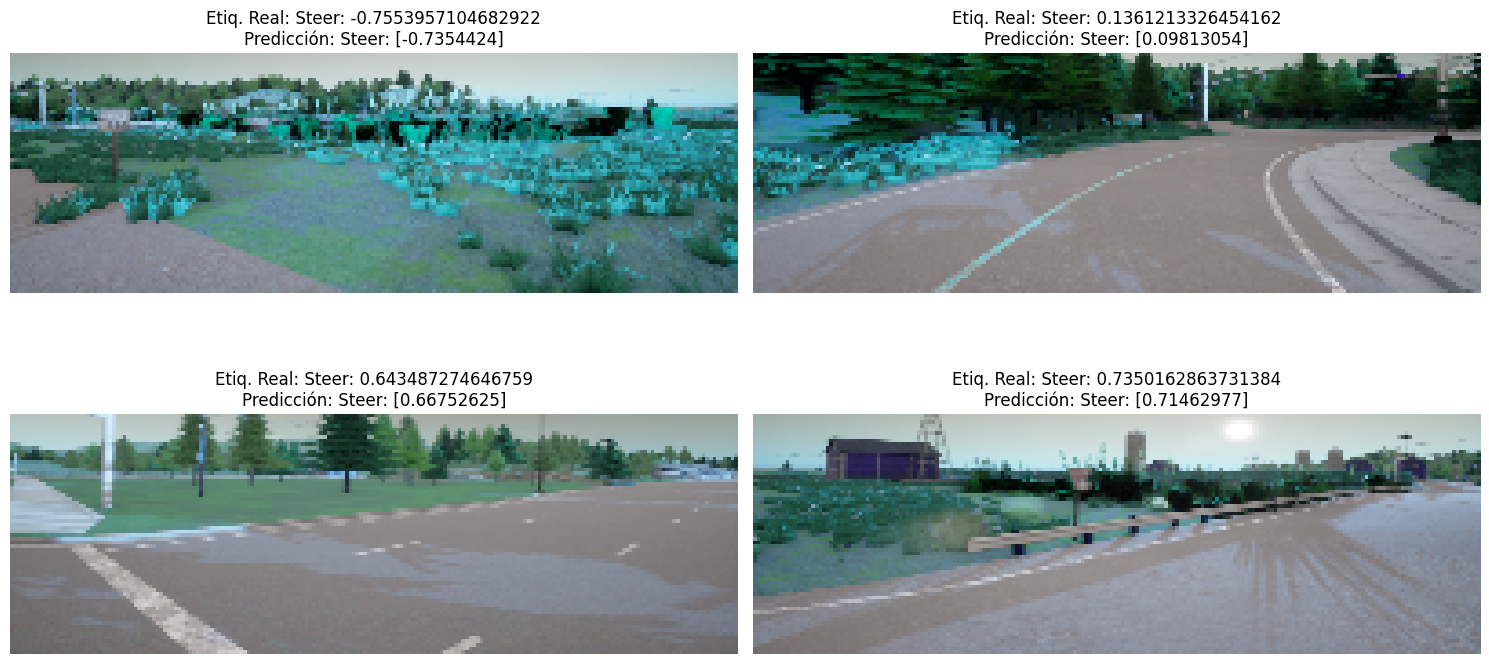

In [33]:
import random
import matplotlib.pyplot as plt
from datetime import datetime
import os
import numpy as np

edicción
predictions = model.predict(X_val)


pred_steering = predictions


print("Shape of pred_steering:", pred_steering.shape)
print("Shape of y_val:", y_val.shape)


sample_indices = random.sample(range(len(X_val)), 4)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(sample_indices, 1):
    plt.subplot(2, 2, i)
    
    plt.imshow(X_val[idx])
    
    real_steering = y_val[idx]
    pred_steering_val = pred_steering[idx]

    plt.title(
        f'Etiq. Real: Steer: {real_steering}\n'
        f'Predicción: Steer: {pred_steering_val}'
    )
    plt.axis('off')

plt.tight_layout()

# os.makedirs('images', exist_ok=True)

# path_name = os.path.join('images/', str(datetime.now().strftime("%Y%m%d_%H%M%S")) + "_" + 'pilotnet' + '_prediccion' + '.png')
# plt.savefig(path_name)
plt.show()


In [34]:
import time
import numpy as np
import tensorflow as tf
from keras.models import load_model
from keras.saving import register_keras_serializable


@register_keras_serializable()
def mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

# model = load_model('/home/canveo/Projects/notebook/model/modelos nuevos/nuevo_dp05_monolitico_epoch_202.h5', custom_objects={'mse': mse})
inferencia
batch_images = X_val[:32]  # Usando las primeras 32 imágenes del conjunto de vafflidación


start_time = time.time()
predictions = model.predict(batch_images)
end_time = time.time()

inference_time = end_time - start_time
print(f"Tiempo de inferencia para un lote de 32 imágenes: {inference_time:.4f} segundos")

average_inference_time = inference_time / len(batch_images)
print(f"Tiempo promedio de inferencia por imagen: {average_inference_time:.6f} segundos")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Tiempo de inferencia para un lote de 32 imágenes: 0.0341 segundos
Tiempo promedio de inferencia por imagen: 0.001066 segundos


3389/3389 ━━━━━━━━━━━━━━━━━━━━ 2s 727us/step


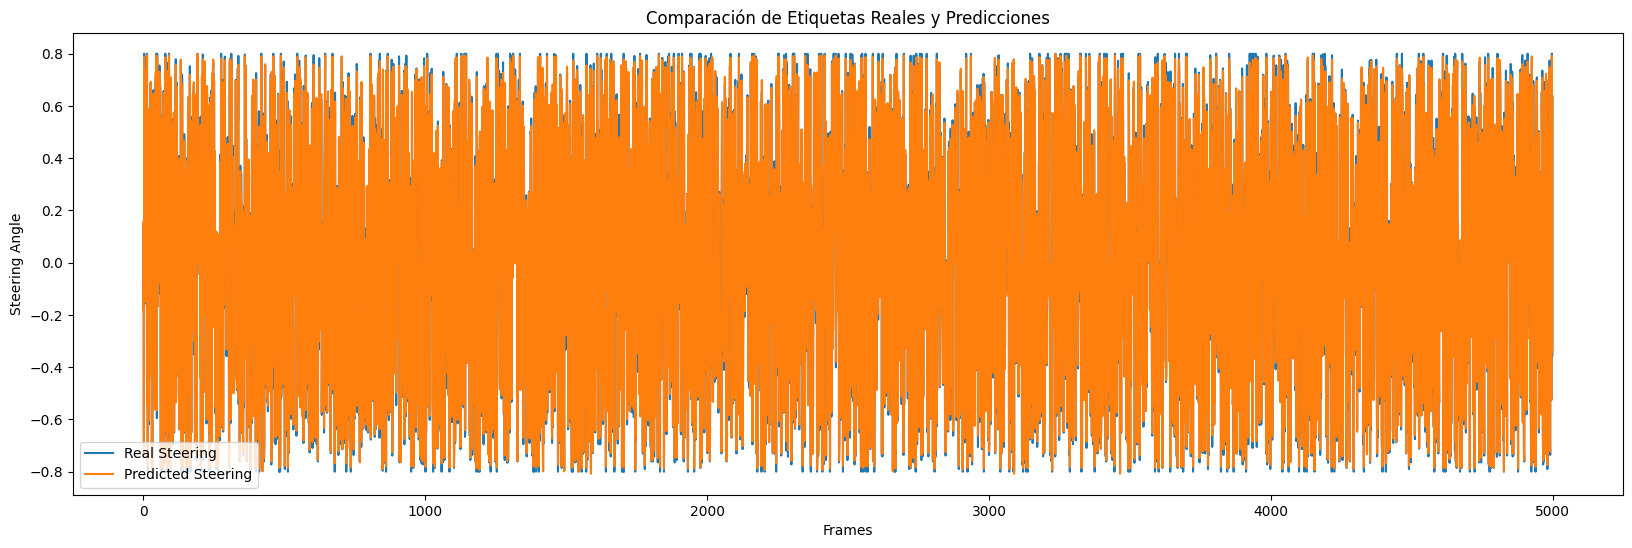

In [41]:
import matplotlib.pyplot as plt
import os
from datetime import datetime

predictions = model.predict(X_val)

pred_steering = predictions


start_idx = 0
end_idx = 5000

plt.figure(figsize=(20, 6))
plt.plot(y_val[start_idx:end_idx], label='Real Steering')
plt.plot(pred_steering[start_idx:end_idx], label='Predicted Steering')
plt.xlabel("Frames")
plt.ylabel("Steering Angle")
plt.legend()
plt.title("Comparación de Etiquetas Reales y Predicciones")


# path_name = os.path.join('images/', str(datetime.now()) + "_" + 'pilotnet' + 'steering' + '.png')
# plt.savefig(path_name)
plt.show()